# PetFinder - Análisis Exploratorio de Datos (EDA Final)

**Dataset:** PetFinder Adoption Prediction  
**Objetivo:** Predecir la velocidad de adopción de mascotas (`AdoptionSpeed`) a partir de datos tabulares, texto e imágenes.

**Target - AdoptionSpeed:**
- `0` — Adoptada el mismo día que fue publicada
- `1` — Adoptada entre 1 y 7 días después de ser publicada
- `2` — Adoptada entre 8 y 30 días después de ser publicada
- `3` — Adoptada entre 31 y 90 días después de ser publicada
- `4` — No fue adoptada después de 100 días

## Descripción de Variables

### Identificadores
| Variable | Descripción |
|---|---|
| `PetID` | ID único (hash) del perfil de la mascota |
| `RescuerID` | ID único (hash) del rescatista |

### Información General
| Variable | Descripción | Valores |
|---|---|---|
| `Type` | Tipo de animal | `1` = Perro, `2` = Gato |
| `Name` | Nombre de la mascota | Vacío si no tiene nombre |
| `Age` | Edad al momento de la publicación | En meses |
| `Gender` | Género | `1` = Macho, `2` = Hembra, `3` = Mixto (perfil grupal) |
| `Quantity` | Cantidad de mascotas representadas en el perfil | Numérico |
| `Fee` | Costo de adopción | `0` = Gratuito |
| `State` | Estado (provincia) en Malasia | Ver `state_labels.csv` |

### Raza y Aspecto Físico
| Variable | Descripción | Valores |
|---|---|---|
| `Breed1` | Raza principal | Ver `breed_labels.csv` |
| `Breed2` | Raza secundaria (si es mestizo) | Ver `breed_labels.csv` |
| `Color1` | Color primario | Ver `color_labels.csv` |
| `Color2` | Color secundario | Ver `color_labels.csv` |
| `Color3` | Color terciario | Ver `color_labels.csv` |
| `MaturitySize` | Tamaño al llegar a la madurez | `0` = No especificado, `1` = Pequeño, `2` = Mediano, `3` = Grande, `4` = Extra Grande |
| `FurLength` | Largo del pelaje | `0` = No especificado, `1` = Corto, `2` = Medio, `3` = Largo |

### Salud
| Variable | Descripción | Valores |
|---|---|---|
| `Vaccinated` | ¿Está vacunada? | `1` = Sí, `2` = No, `3` = No sabe |
| `Dewormed` | ¿Está desparasitada? | `1` = Sí, `2` = No, `3` = No sabe |
| `Sterilized` | ¿Está esterilizada/castrada? | `1` = Sí, `2` = No, `3` = No sabe |
| `Health` | Condición de salud | `0` = No especificado, `1` = Sano, `2` = Lesión leve, `3` = Lesión grave |

### Contenido Multimedia y Texto
| Variable | Descripción |
|---|---|
| `Description` | Texto descriptivo del perfil de la mascota (principalmente en inglés) |
| `PhotoAmt` | Cantidad de fotos subidas |
| `VideoAmt` | Cantidad de videos subidos |

### Target
| Variable | Descripción | Valores |
|---|---|---|
| `AdoptionSpeed` | Velocidad de adopción (a predecir) | `0` = Mismo día, `1` = 1-7 días, `2` = 8-30 días, `3` = 31-90 días, `4` = No adoptada |

## 1. Importación de Librerías

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = [12.0, 6.0]
sns.set_style('whitegrid')

## 2. Carga de Datos

In [58]:
train = pd.read_csv('../input/petfinder-adoption-prediction/train/train.csv')
breed_labels  = pd.read_csv('../input/petfinder-adoption-prediction/breed_labels.csv')
color_labels  = pd.read_csv('../input/petfinder-adoption-prediction/color_labels.csv')
state_labels  = pd.read_csv('../input/petfinder-adoption-prediction/state_labels.csv')

print(f'Train shape: {train.shape}')

Train shape: (14993, 24)


## 3. Exploración Inicial

In [59]:
train.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


In [60]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  object 
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 17  State          14993 non-null  int64  
 18  Rescue

In [61]:
train.describe()

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000
mean,1.457614,10.452078,265.272594,74.009738,1.776162,2.234176,3.222837,1.882012,1.862002,1.467485,1.731208,1.558727,1.914227,1.036617,1.576069,21.259988,41346.028347,0.056760,3.889215,2.516441
std,0.498217,18.155790,60.056818,123.011575,0.681592,1.745225,2.742562,2.984086,0.547959,0.599070,0.667649,0.695817,0.566172,0.199535,1.472477,78.414548,32.444153,0.346185,3.487810,1.177265
min,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,41324.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,265.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,2.000000,2.000000
50%,1.000000,3.000000,266.000000,0.000000,2.000000,2.000000,2.000000,0.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,3.000000,2.000000
75%,2.000000,12.000000,307.000000,179.000000,2.000000,3.000000,6.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,41401.000000,0.000000,5.000000,4.000000
max,2.000000,255.000000,307.000000,307.000000,3.000000,7.000000,7.000000,7.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,20.000000,3000.000000,41415.000000,8.000000,30.000000,4.000000


### 3.1 Valores Nulos

Columnas con valores nulos:
Name           1265
Description      13
dtype: int64


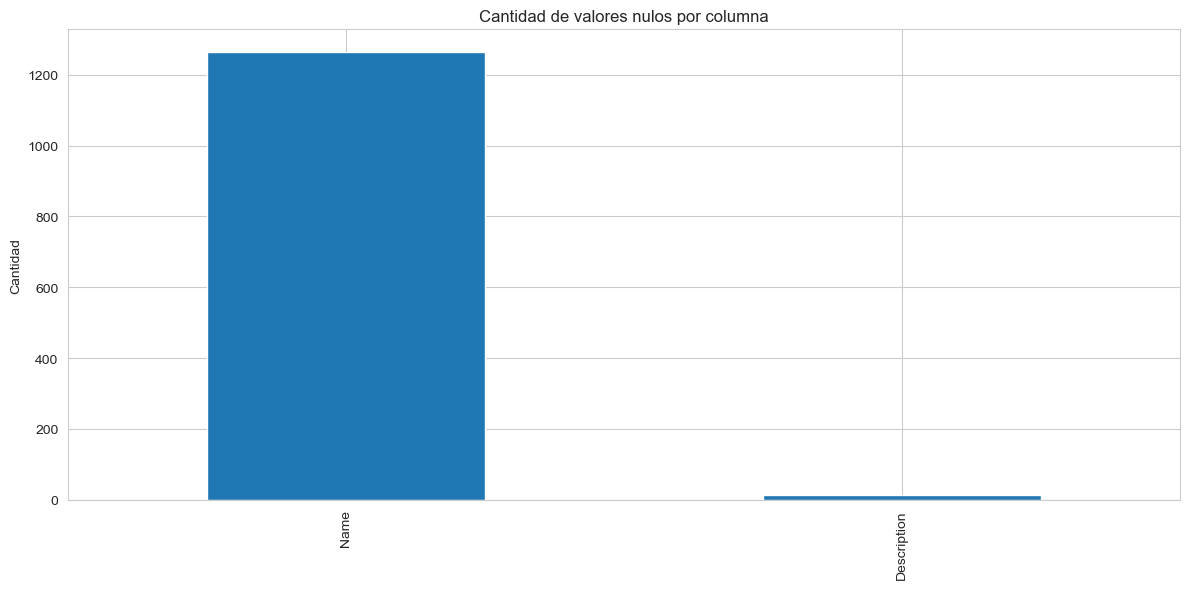

In [62]:
nulos = train.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print('Columnas con valores nulos:')
print(nulos)

if len(nulos) > 0:
    nulos.plot(kind='bar')
    plt.title('Cantidad de valores nulos por columna')
    plt.ylabel('Cantidad')
    plt.tight_layout()
    plt.show()
else:
    print('No hay valores nulos en el dataset.')

## 4. Variable Target: AdoptionSpeed

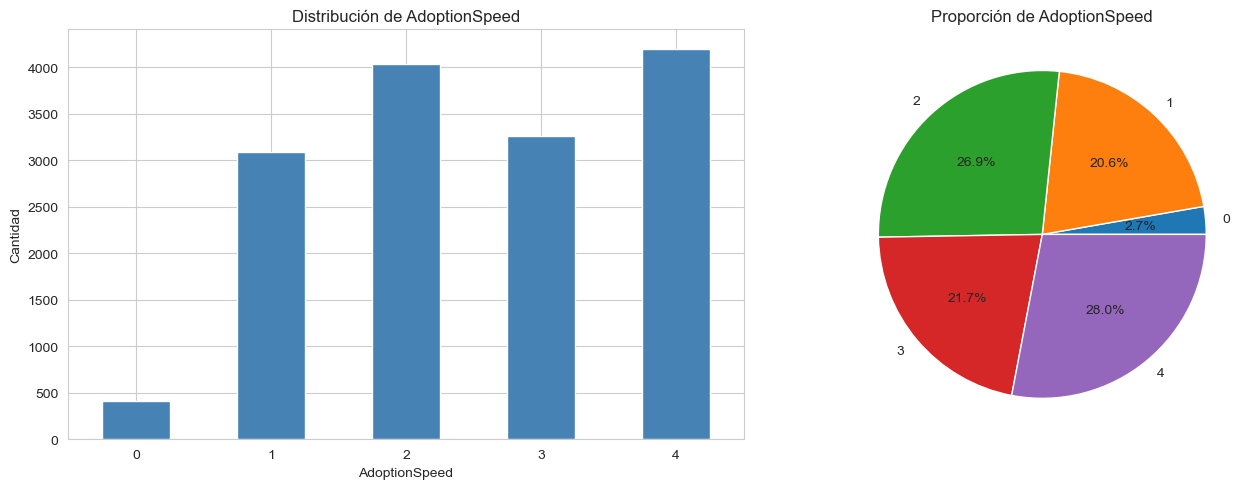

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train['AdoptionSpeed'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de AdoptionSpeed')
axes[0].set_xlabel('AdoptionSpeed')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

train['AdoptionSpeed'].value_counts().sort_index().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Proporción de AdoptionSpeed')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Tipo de Mascota (Perro vs Gato)

C:\Users\tomi_\AppData\Local\Temp\ipykernel_31256\1048297929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type_label', data=train, ax=axes[0], palette='Set2')


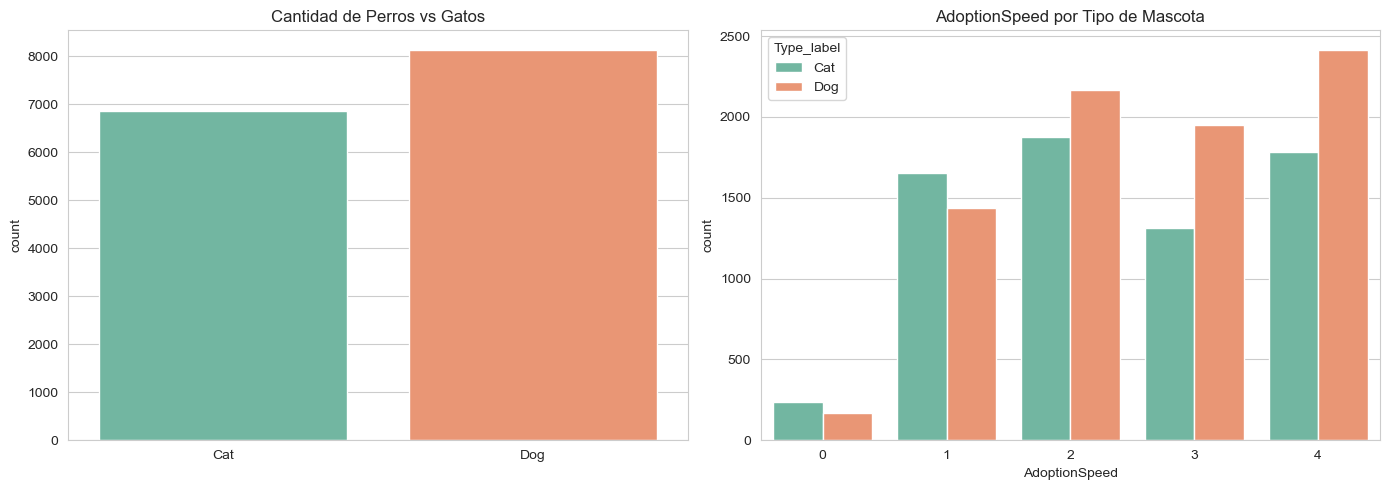

In [64]:
train['Type_label'] = train['Type'].map({1: 'Dog', 2: 'Cat'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Type_label', data=train, ax=axes[0], palette='Set2')
axes[0].set_title('Cantidad de Perros vs Gatos')
axes[0].set_xlabel('')

sns.countplot(x='AdoptionSpeed', data=train, hue='Type_label', ax=axes[1], palette='Set2')
axes[1].set_title('AdoptionSpeed por Tipo de Mascota')
axes[1].set_xlabel('AdoptionSpeed')

plt.tight_layout()
plt.show()

## 6. Variables Numéricas

### 6.1 Edad (Age)

C:\Users\tomi_\AppData\Local\Temp\ipykernel_31256\4029995890.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y='Age', data=train, ax=axes[1], palette='Set2')


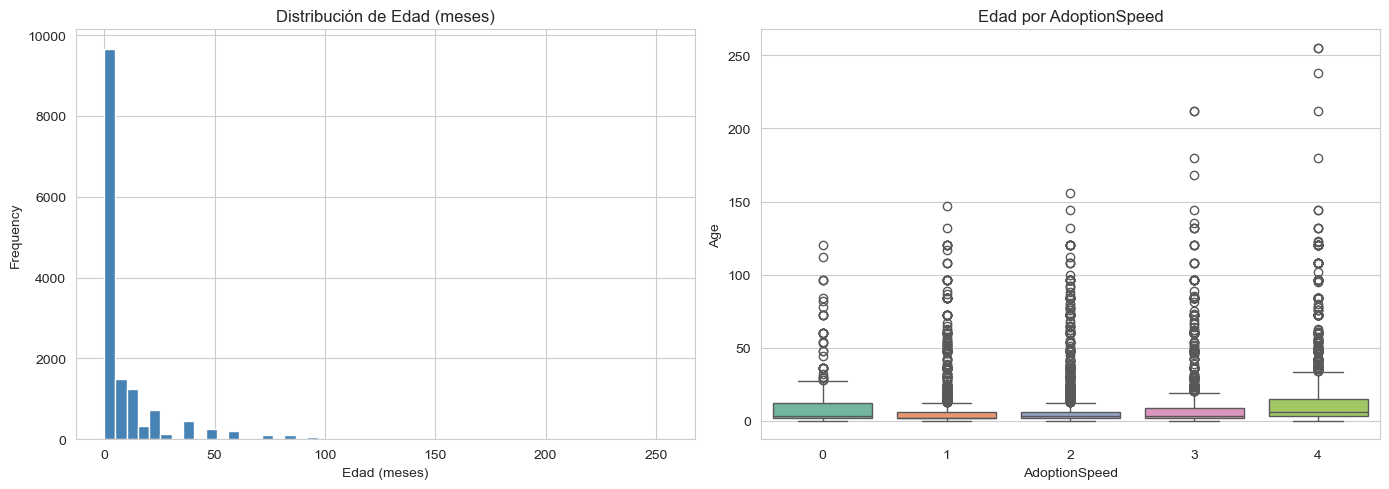

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train['Age'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Edad (meses)')
axes[0].set_xlabel('Edad (meses)')

sns.boxplot(x='AdoptionSpeed', y='Age', data=train, ax=axes[1], palette='Set2')
axes[1].set_title('Edad por AdoptionSpeed')

plt.tight_layout()
plt.show()

### 6.2 Fee (Costo de Adopción)

C:\Users\tomi_\AppData\Local\Temp\ipykernel_31256\2891690805.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Gratuita', 'Con Costo'])


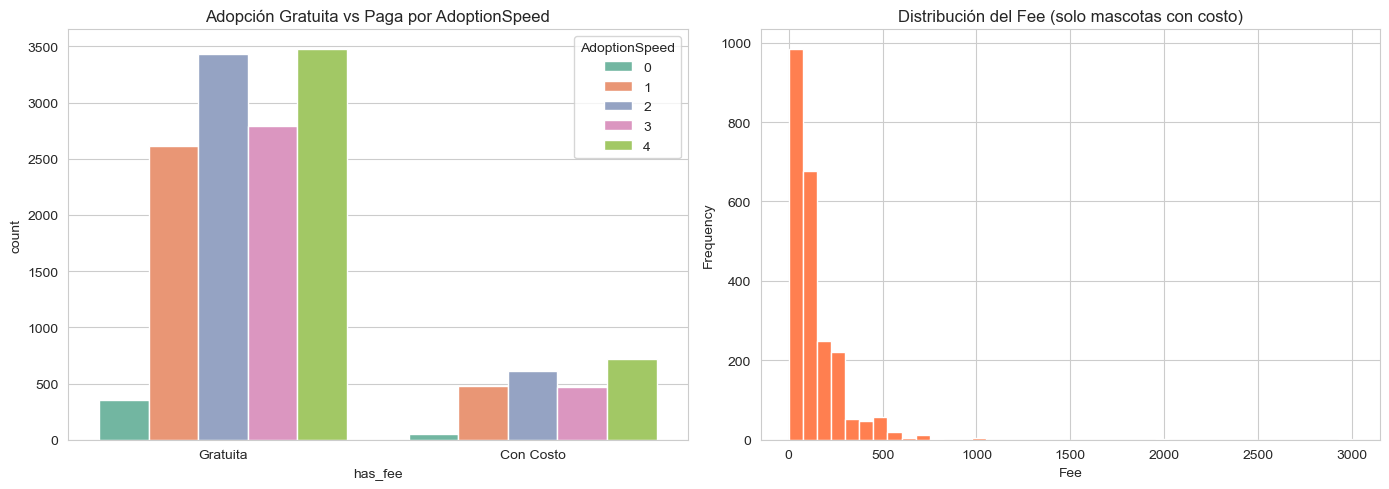

In [66]:
train['has_fee'] = (train['Fee'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='has_fee', data=train, hue='AdoptionSpeed', ax=axes[0], palette='Set2')
axes[0].set_title('Adopción Gratuita vs Paga por AdoptionSpeed')
axes[0].set_xticklabels(['Gratuita', 'Con Costo'])

train.loc[train['Fee'] > 0, 'Fee'].plot(kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribución del Fee (solo mascotas con costo)')
axes[1].set_xlabel('Fee')

plt.tight_layout()
plt.show()

### 6.3 Fotos y Videos

C:\Users\tomi_\AppData\Local\Temp\ipykernel_31256\2272644519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y='PhotoAmt', data=train, ax=axes[0], palette='Set2')
C:\Users\tomi_\AppData\Local\Temp\ipykernel_31256\2272644519.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y='VideoAmt', data=train, ax=axes[1], palette='Set2')


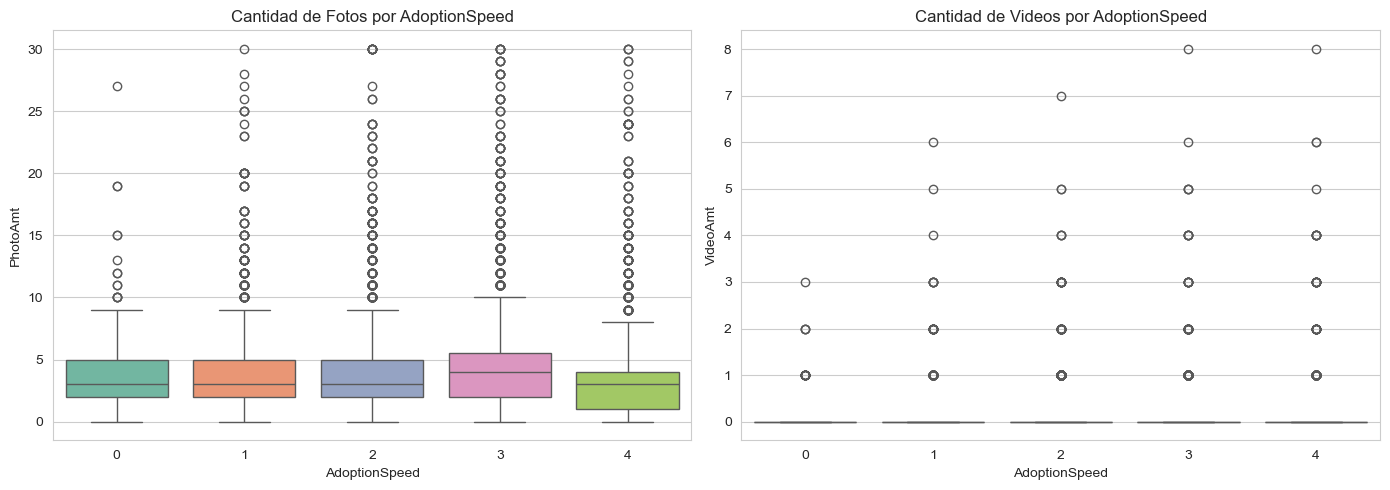

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='AdoptionSpeed', y='PhotoAmt', data=train, ax=axes[0], palette='Set2')
axes[0].set_title('Cantidad de Fotos por AdoptionSpeed')

sns.boxplot(x='AdoptionSpeed', y='VideoAmt', data=train, ax=axes[1], palette='Set2')
axes[1].set_title('Cantidad de Videos por AdoptionSpeed')

plt.tight_layout()
plt.show()

### 6.4 Cantidad de Mascotas por Perfil (Quantity)

In [68]:
print("Distribución de Quantity:")
print(train['Quantity'].value_counts().sort_index())
print(f"\nMáximo: {train['Quantity'].max()}  |  Mediana: {train['Quantity'].median()}  |  Media: {train['Quantity'].mean():.2f}")

Distribución de Quantity:
Quantity
1     11565
2      1422
3       726
4       531
5       333
6       185
7        84
8        52
9        33
10       19
11       10
12        6
13        2
14        2
15        4
16        3
17        3
18        1
20       12
Name: count, dtype: int64

Máximo: 20  |  Mediana: 1.0  |  Media: 1.58


C:\Users\tomi_\AppData\Local\Temp\ipykernel_31256\18968956.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type_label', y='Quantity', data=train, ax=axes[2], palette='Set2')


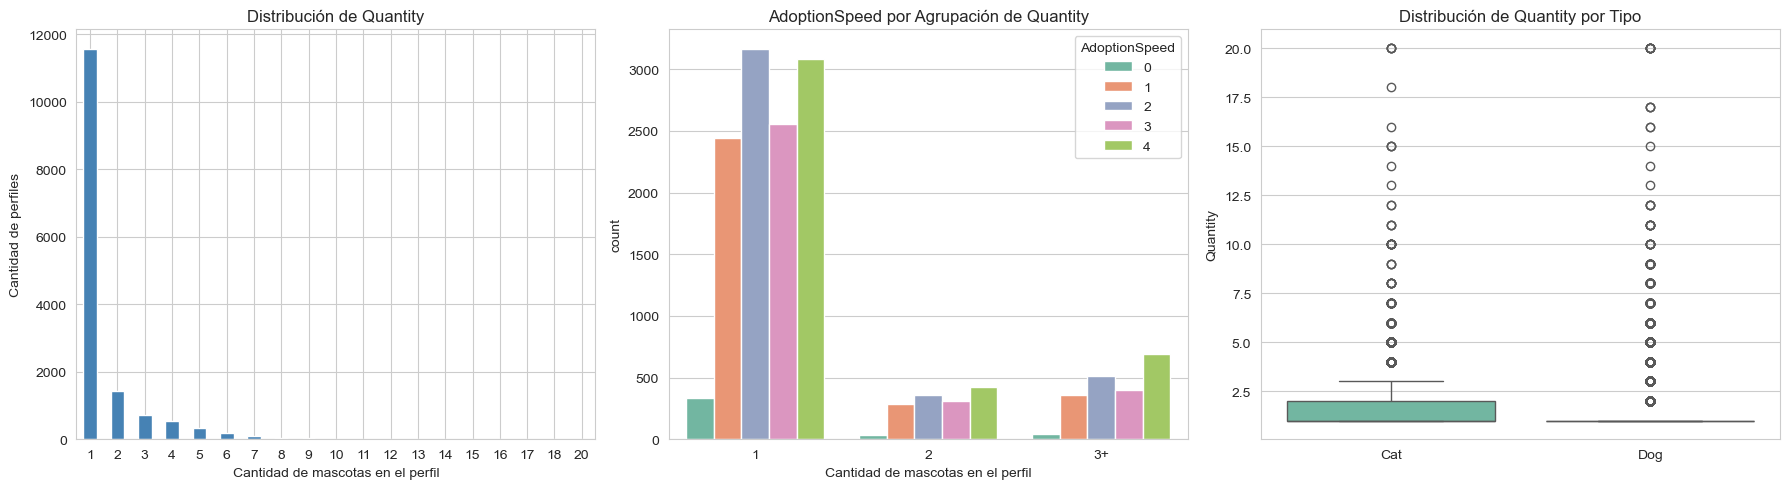

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución general
train['Quantity'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Quantity')
axes[0].set_xlabel('Cantidad de mascotas en el perfil')
axes[0].set_ylabel('Cantidad de perfiles')
axes[0].tick_params(axis='x', rotation=0)

# Quantity agrupada: 1 vs 2 vs 3+
train['Quantity_group'] = train['Quantity'].apply(lambda x: '1' if x == 1 else ('2' if x == 2 else '3+'))
qty_order = ['1', '2', '3+']
sns.countplot(x='Quantity_group', data=train, hue='AdoptionSpeed', order=qty_order, ax=axes[1], palette='Set2')
axes[1].set_title('AdoptionSpeed por Agrupación de Quantity')
axes[1].set_xlabel('Cantidad de mascotas en el perfil')

# Quantity por tipo de mascota
sns.boxplot(x='Type_label', y='Quantity', data=train, ax=axes[2], palette='Set2')
axes[2].set_title('Distribución de Quantity por Tipo')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

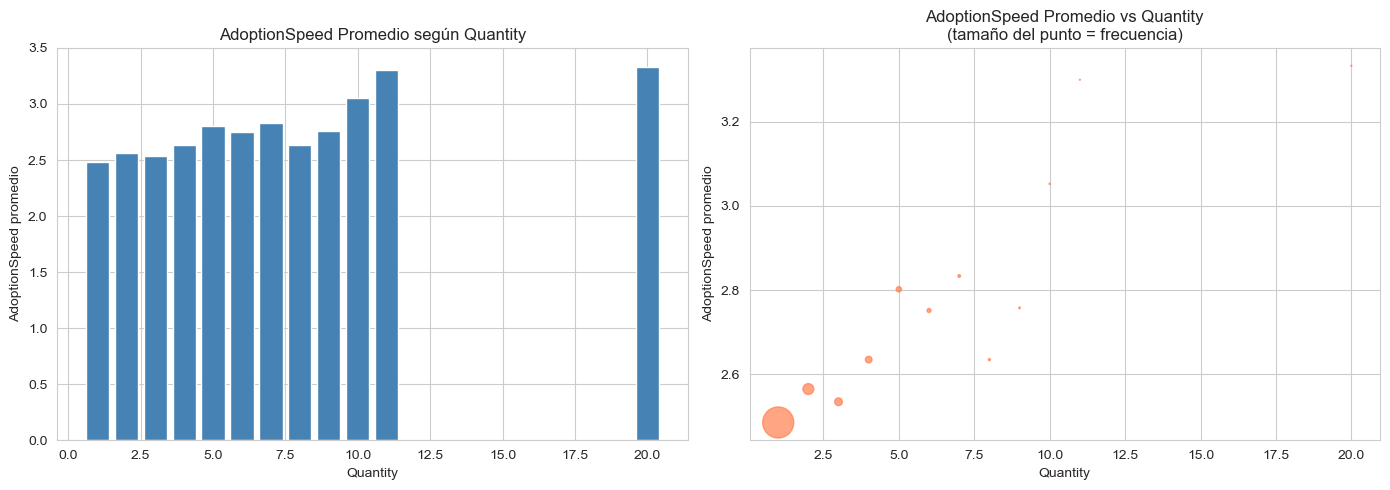

In [70]:
# AdoptionSpeed promedio según Quantity (continua)
qty_adoption = train.groupby('Quantity')['AdoptionSpeed'].agg(['mean', 'count']).reset_index()
qty_adoption.columns = ['Quantity', 'AdoptionSpeed_mean', 'count']
qty_adoption = qty_adoption[qty_adoption['count'] >= 10]  # filtrar valores con pocas observaciones

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(qty_adoption['Quantity'], qty_adoption['AdoptionSpeed_mean'], color='steelblue')
axes[0].set_title('AdoptionSpeed Promedio según Quantity')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('AdoptionSpeed promedio')

axes[1].scatter(qty_adoption['Quantity'], qty_adoption['AdoptionSpeed_mean'],
                s=qty_adoption['count'] / qty_adoption['count'].max() * 500,
                alpha=0.7, color='coral')
axes[1].set_title('AdoptionSpeed Promedio vs Quantity\n(tamaño del punto = frecuencia)')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('AdoptionSpeed promedio')

plt.tight_layout()
plt.show()

## 7. Variables Categóricas

### 7.1 Género

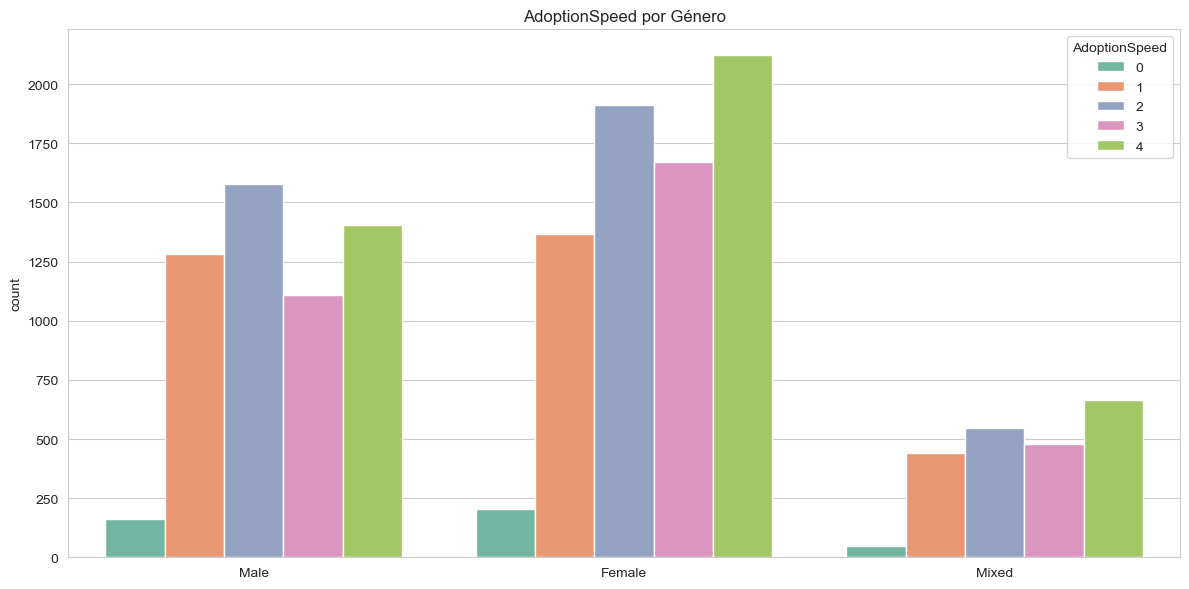

In [71]:
train['Gender_label'] = train['Gender'].map({1: 'Male', 2: 'Female', 3: 'Mixed'})

sns.countplot(x='Gender_label', data=train, hue='AdoptionSpeed', palette='Set2')
plt.title('AdoptionSpeed por Género')
plt.xlabel('')
plt.tight_layout()
plt.show()

### 7.2 Variables de Salud (Vacunación, Desparasitación, Esterilización)

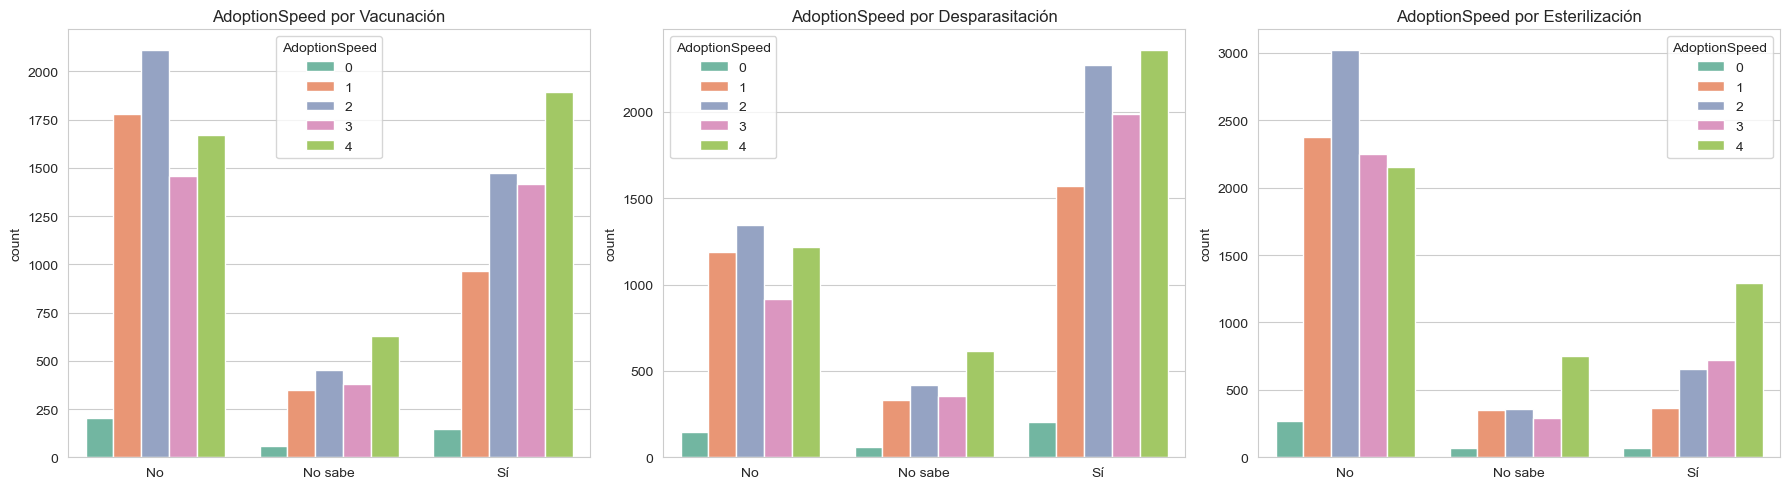

In [72]:
label_map = {1: 'Sí', 2: 'No', 3: 'No sabe'}
train['Vaccinated_label']  = train['Vaccinated'].map(label_map)
train['Dewormed_label']    = train['Dewormed'].map(label_map)
train['Sterilized_label']  = train['Sterilized'].map(label_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes,
                          ['Vaccinated_label', 'Dewormed_label', 'Sterilized_label'],
                          ['Vacunación', 'Desparasitación', 'Esterilización']):
    sns.countplot(x=col, data=train, hue='AdoptionSpeed', ax=ax, palette='Set2')
    ax.set_title(f'AdoptionSpeed por {title}')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### 7.3 Condición de Salud

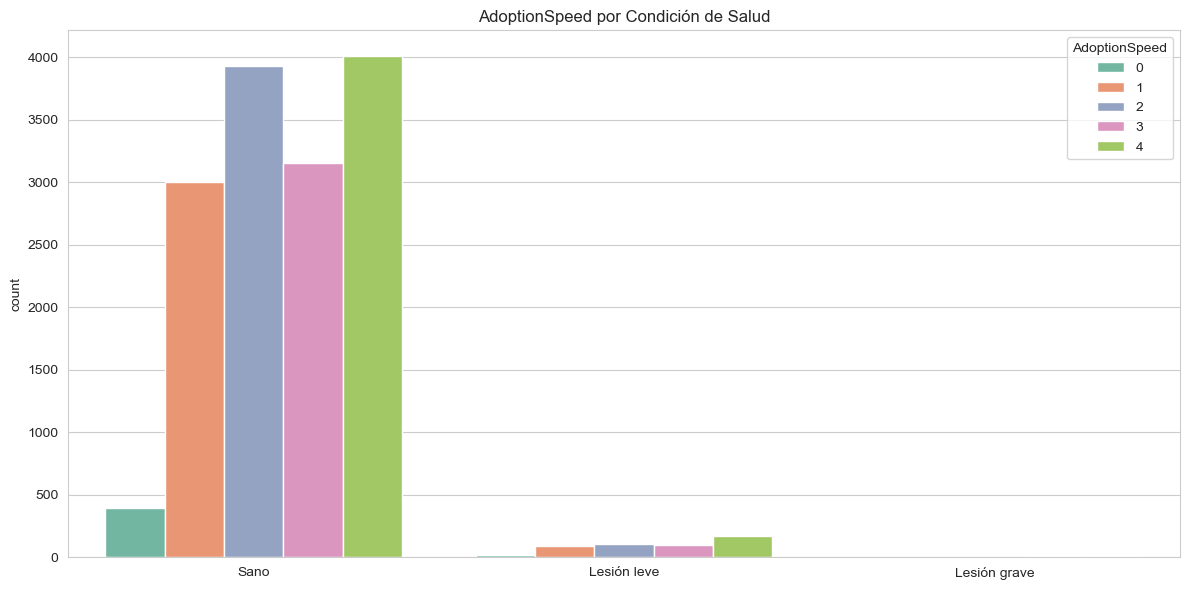

In [73]:
health_map = {0: 'No especificado', 1: 'Sano', 2: 'Lesión leve', 3: 'Lesión grave'}
train['Health_label'] = train['Health'].map(health_map)

sns.countplot(x='Health_label', data=train, hue='AdoptionSpeed', palette='Set2')
plt.title('AdoptionSpeed por Condición de Salud')
plt.xlabel('')
plt.tight_layout()
plt.show()

### 7.4 Tamaño y Pelaje

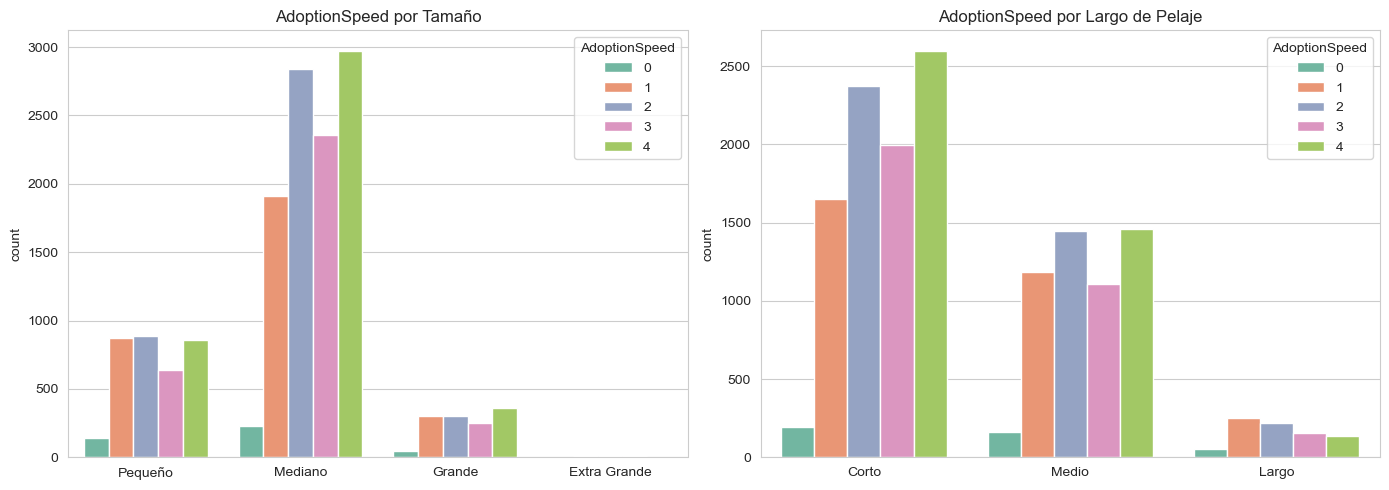

In [74]:
size_map    = {0: 'No especificado', 1: 'Pequeño', 2: 'Mediano', 3: 'Grande', 4: 'Extra Grande'}
fur_map     = {0: 'No especificado', 1: 'Corto', 2: 'Medio', 3: 'Largo'}
train['MaturitySize_label'] = train['MaturitySize'].map(size_map)
train['FurLength_label']    = train['FurLength'].map(fur_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='MaturitySize_label', data=train, hue='AdoptionSpeed', ax=axes[0], palette='Set2')
axes[0].set_title('AdoptionSpeed por Tamaño')
axes[0].set_xlabel('')

sns.countplot(x='FurLength_label', data=train, hue='AdoptionSpeed', ax=axes[1], palette='Set2')
axes[1].set_title('AdoptionSpeed por Largo de Pelaje')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 7.5 Razas más Frecuentes

## 8. Análisis Bivariado: Gatos vs Perros respecto al Target

En esta sección se analiza cómo se relaciona `AdoptionSpeed` con distintas variables, **separando el comportamiento por tipo de mascota** (Gato / Perro).

### Matrices de Correlación por Tipo de Mascota

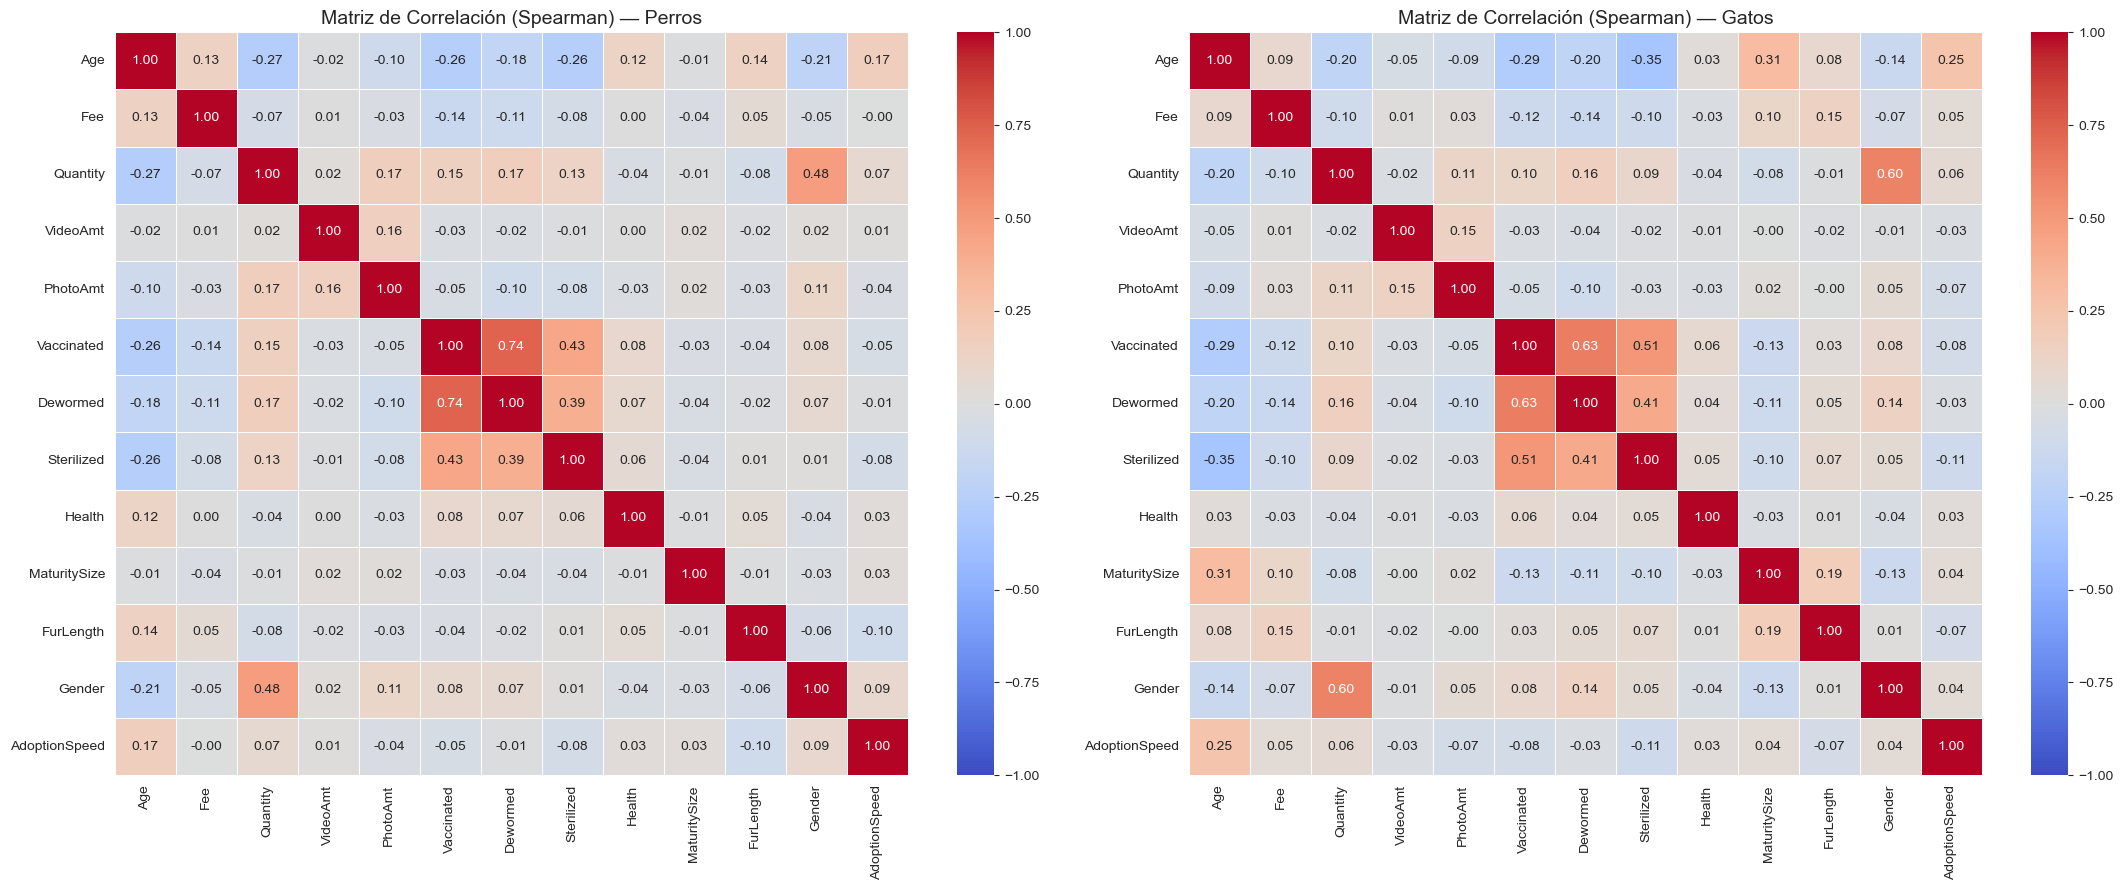

In [75]:
num_cols = ['Age', 'Fee', 'Quantity', 'VideoAmt', 'PhotoAmt',
            'Vaccinated', 'Dewormed', 'Sterilized', 'Health',
            'MaturitySize', 'FurLength', 'Gender', 'AdoptionSpeed']

dogs = train[train['Type_label'] == 'Dog']
cats = train[train['Type_label'] == 'Cat']

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, subset, title in zip(axes, [dogs, cats], ['Perros', 'Gatos']):
    corr = subset[num_cols].corr(method='spearman')  # <-- único cambio
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f'Matriz de Correlación (Spearman) — {title}', fontsize=14)

plt.tight_layout()
plt.show()

### 8.1 Género por Tipo

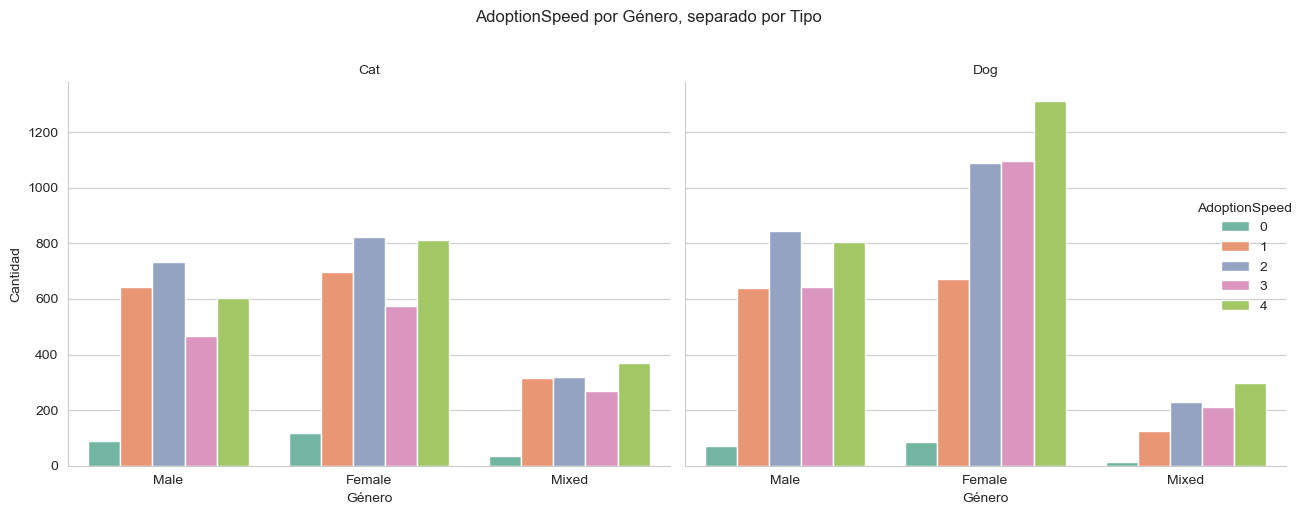

Gender_label    Female      Male     Mixed
Type_label                                
Cat           2.419174  2.336231  2.476628
Dog           2.677093  2.488186  2.749714


In [76]:
g = sns.FacetGrid(train, col='Type_label', height=5, aspect=1.2, palette='Set2')
g.map_dataframe(sns.countplot, x='Gender_label', hue='AdoptionSpeed',
                order=['Male', 'Female', 'Mixed'], palette='Set2')
g.add_legend(title='AdoptionSpeed')
g.set_axis_labels('Género', 'Cantidad')
g.set_titles(col_template='{col_name}')
plt.suptitle('AdoptionSpeed por Género, separado por Tipo', y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen: AdoptionSpeed promedio por Género y Tipo
print(train.groupby(['Type_label', 'Gender_label'])['AdoptionSpeed'].mean().unstack())

### 8.2 Edad por Tipo

C:\Users\tomi_\AppData\Local\Temp\ipykernel_31256\1565522959.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y='Age', data=subset, ax=ax, palette='Set2')
C:\Users\tomi_\AppData\Local\Temp\ipykernel_31256\1565522959.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y='Age', data=subset, ax=ax, palette='Set2')


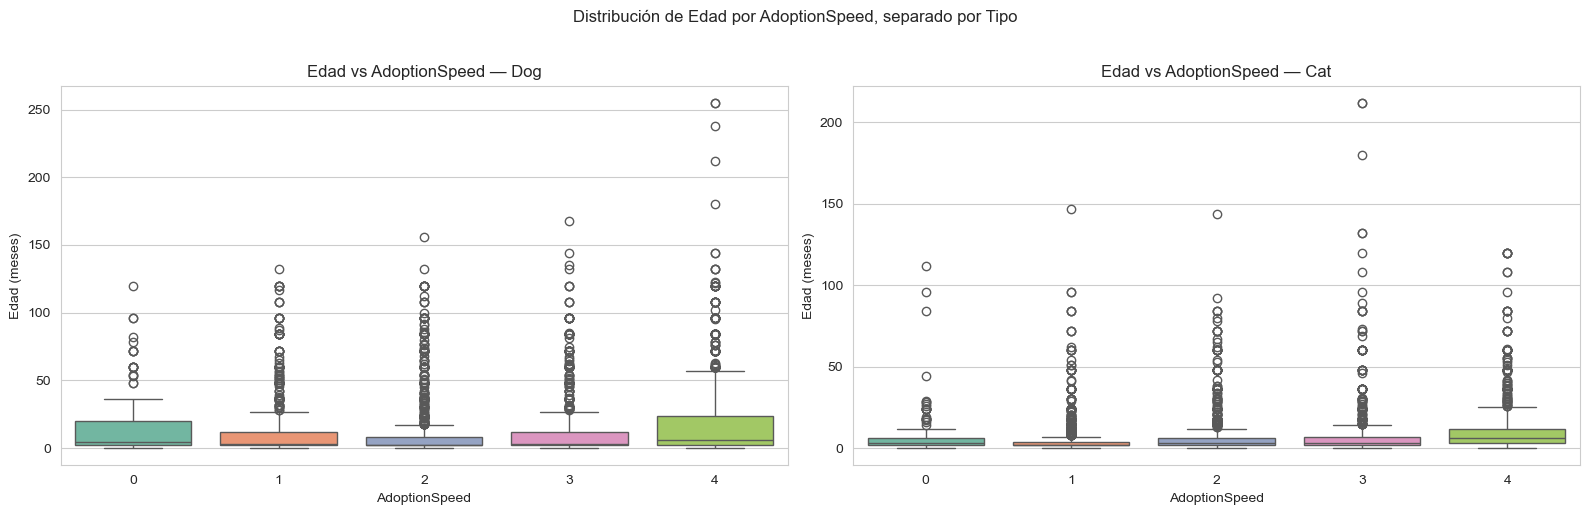

Mediana de Edad por AdoptionSpeed y Tipo:
AdoptionSpeed    0    1    2    3    4
Type_label                            
Cat            3.0  2.0  3.0  3.0  6.0
Dog            4.5  3.0  2.0  3.0  6.0


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, animal in zip(axes, ['Dog', 'Cat']):
    subset = train[train['Type_label'] == animal]
    sns.boxplot(x='AdoptionSpeed', y='Age', data=subset, ax=ax, palette='Set2')
    ax.set_title(f'Edad vs AdoptionSpeed — {animal}')
    ax.set_xlabel('AdoptionSpeed')
    ax.set_ylabel('Edad (meses)')

plt.suptitle('Distribución de Edad por AdoptionSpeed, separado por Tipo', y=1.02)
plt.tight_layout()
plt.show()

# Tabla: mediana de edad por AdoptionSpeed y Tipo
print("Mediana de Edad por AdoptionSpeed y Tipo:")
print(train.groupby(['Type_label', 'AdoptionSpeed'])['Age'].median().unstack())

### 8.3 Tamaño por Tipo

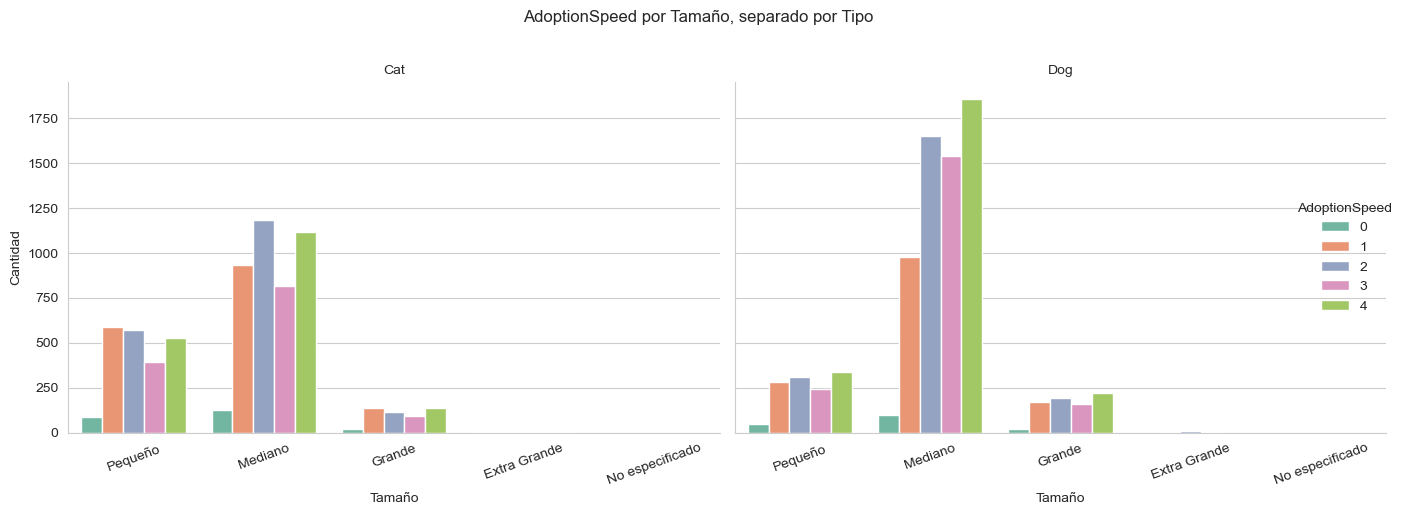

AdoptionSpeed promedio por Tamaño y Tipo:
MaturitySize_label  Extra Grande  Grande  Mediano  Pequeño
Type_label                                                
Cat                         2.45    2.37     2.45     2.31
Dog                         2.00    2.51     2.67     2.43


In [78]:
size_order = ['Pequeño', 'Mediano', 'Grande', 'Extra Grande', 'No especificado']

g = sns.FacetGrid(train, col='Type_label', height=5, aspect=1.3)
g.map_dataframe(sns.countplot, x='MaturitySize_label', hue='AdoptionSpeed',
                order=size_order, palette='Set2')
g.add_legend(title='AdoptionSpeed')
g.set_axis_labels('Tamaño', 'Cantidad')
g.set_titles(col_template='{col_name}')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('AdoptionSpeed por Tamaño, separado por Tipo', y=1.02)
plt.tight_layout()
plt.show()

print("AdoptionSpeed promedio por Tamaño y Tipo:")
print(train.groupby(['Type_label', 'MaturitySize_label'])['AdoptionSpeed'].mean().unstack().round(2))

### 8.4 Vacunación por Tipo

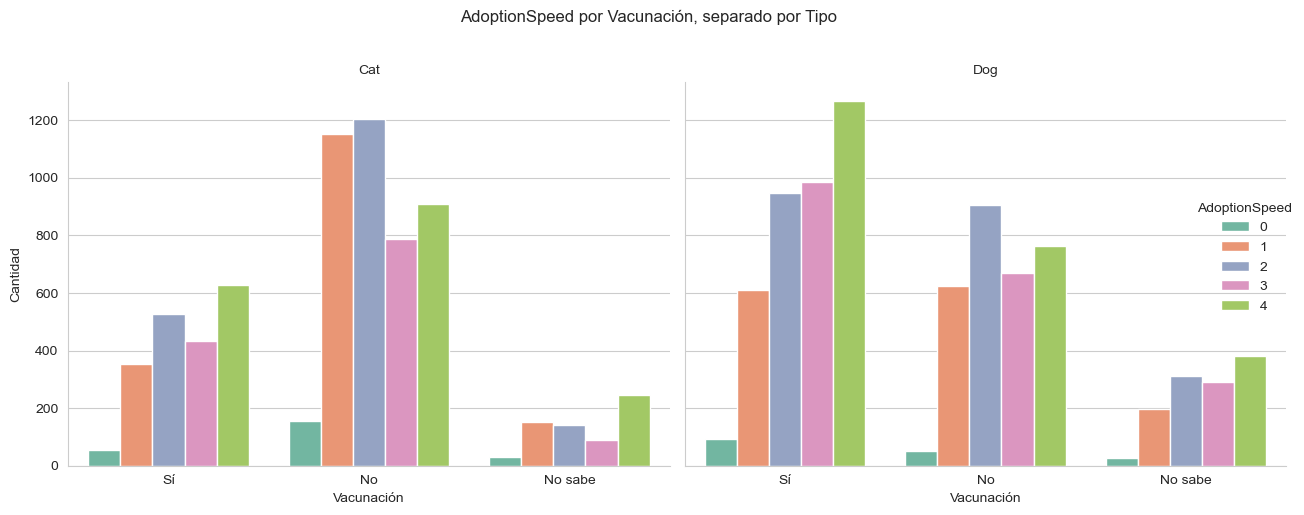

AdoptionSpeed promedio por Vacunación y Tipo:
Vaccinated_label    No  No sabe    Sí
Type_label                           
Cat               2.27     2.56  2.62
Dog               2.49     2.67  2.70


In [79]:
vacc_order = ['Sí', 'No', 'No sabe']

g = sns.FacetGrid(train, col='Type_label', height=5, aspect=1.2)
g.map_dataframe(sns.countplot, x='Vaccinated_label', hue='AdoptionSpeed',
                order=vacc_order, palette='Set2')
g.add_legend(title='AdoptionSpeed')
g.set_axis_labels('Vacunación', 'Cantidad')
g.set_titles(col_template='{col_name}')
plt.suptitle('AdoptionSpeed por Vacunación, separado por Tipo', y=1.02)
plt.tight_layout()
plt.show()

print("AdoptionSpeed promedio por Vacunación y Tipo:")
print(train.groupby(['Type_label', 'Vaccinated_label'])['AdoptionSpeed'].mean().unstack().round(2))

### 8.5 Condición de Salud por Tipo

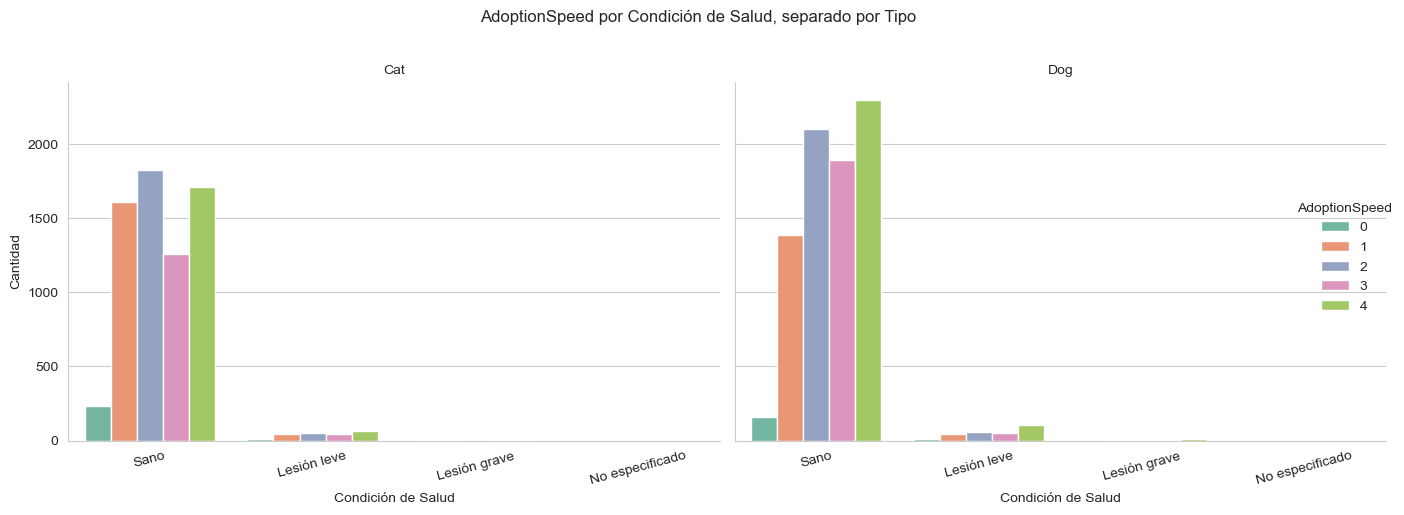

AdoptionSpeed promedio por Condición de Salud y Tipo:
Health_label  Lesión grave  Lesión leve  Sano
Type_label                                   
Cat                   3.00         2.55  2.39
Dog                   3.05         2.74  2.61


In [80]:
health_order = ['Sano', 'Lesión leve', 'Lesión grave', 'No especificado']

g = sns.FacetGrid(train, col='Type_label', height=5, aspect=1.3)
g.map_dataframe(sns.countplot, x='Health_label', hue='AdoptionSpeed',
                order=health_order, palette='Set2')
g.add_legend(title='AdoptionSpeed')
g.set_axis_labels('Condición de Salud', 'Cantidad')
g.set_titles(col_template='{col_name}')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('AdoptionSpeed por Condición de Salud, separado por Tipo', y=1.02)
plt.tight_layout()
plt.show()

print("AdoptionSpeed promedio por Condición de Salud y Tipo:")
print(train.groupby(['Type_label', 'Health_label'])['AdoptionSpeed'].mean().unstack().round(2))

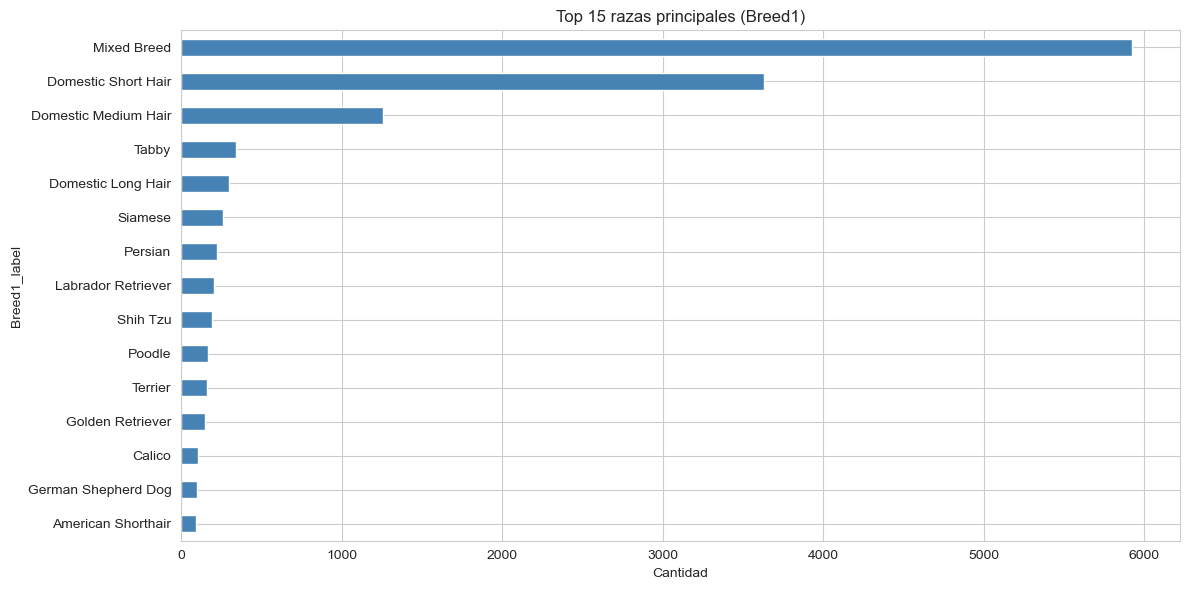

In [81]:
# Unir con etiquetas de raza
breed_map = breed_labels.set_index('BreedID')['BreedName'].to_dict()
train['Breed1_label'] = train['Breed1'].map(breed_map)

top_n = 15
top_breeds = train['Breed1_label'].value_counts().head(top_n)

top_breeds.sort_values().plot(kind='barh', color='steelblue')
plt.title(f'Top {top_n} razas principales (Breed1)')
plt.xlabel('Cantidad')
plt.tight_layout()
plt.show()

### 7.6 Estado Geográfico

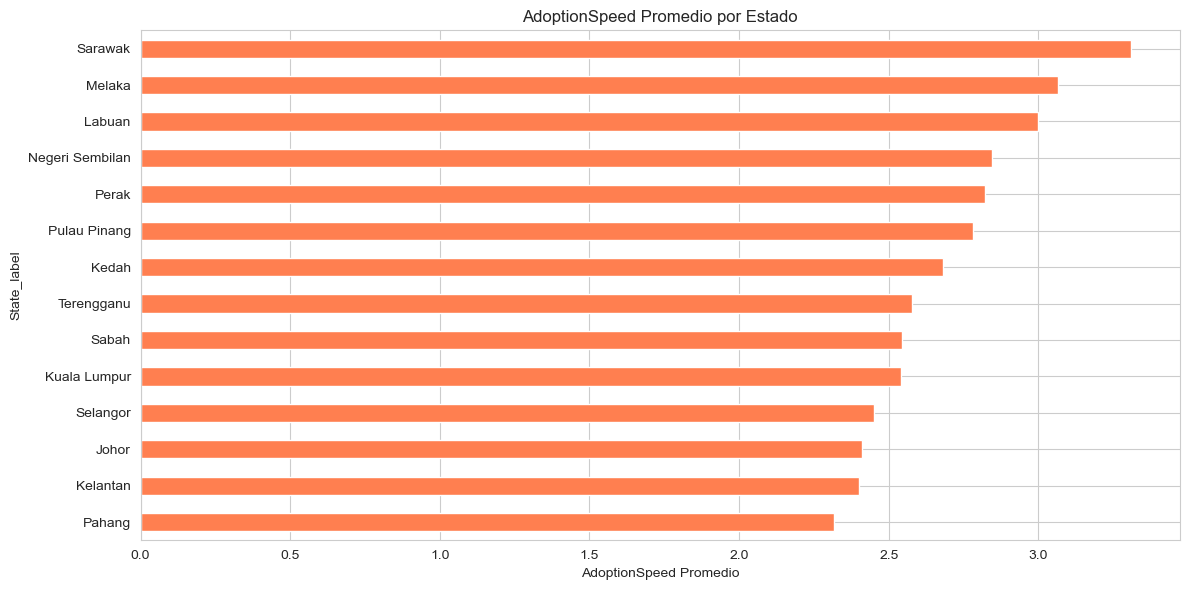

In [82]:
state_map = state_labels.set_index('StateID')['StateName'].to_dict()
train['State_label'] = train['State'].map(state_map)

state_counts = train.groupby('State_label')['AdoptionSpeed'].mean().sort_values()

state_counts.plot(kind='barh', color='coral')
plt.title('AdoptionSpeed Promedio por Estado')
plt.xlabel('AdoptionSpeed Promedio')
plt.tight_layout()
plt.show()

## 8. Matriz de Correlación

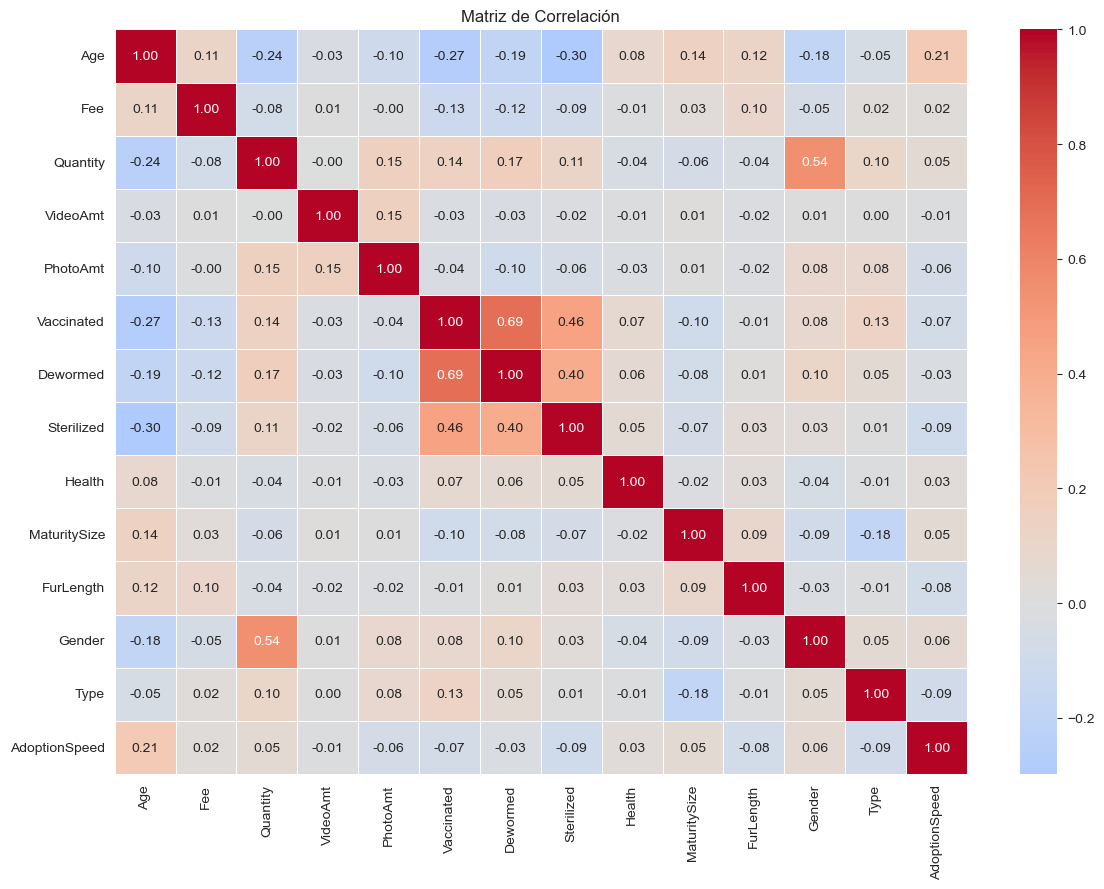

In [83]:
num_cols = ['Age', 'Fee', 'Quantity', 'VideoAmt', 'PhotoAmt',
            'Vaccinated', 'Dewormed', 'Sterilized', 'Health',
            'MaturitySize', 'FurLength', 'Gender', 'Type', 'AdoptionSpeed']

corr = train[num_cols].corr(method='spearman')

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

## 9. Análisis de Texto: Description

C:\Users\tomi_\AppData\Local\Temp\ipykernel_31256\4126150813.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y='desc_len', data=train, ax=axes[0], palette='Set2')
C:\Users\tomi_\AppData\Local\Temp\ipykernel_31256\4126150813.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AdoptionSpeed', y='desc_words', data=train, ax=axes[1], palette='Set2')


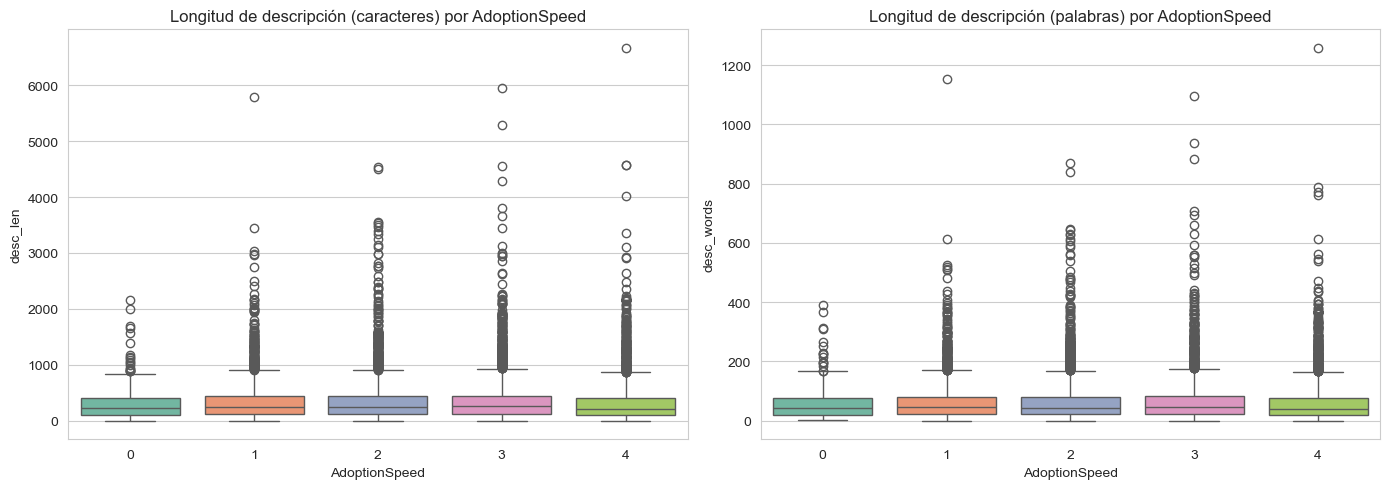

In [84]:
train['desc_len'] = train['Description'].fillna('').apply(len)
train['desc_words'] = train['Description'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='AdoptionSpeed', y='desc_len', data=train, ax=axes[0], palette='Set2')
axes[0].set_title('Longitud de descripción (caracteres) por AdoptionSpeed')

sns.boxplot(x='AdoptionSpeed', y='desc_words', data=train, ax=axes[1], palette='Set2')
axes[1].set_title('Longitud de descripción (palabras) por AdoptionSpeed')

plt.tight_layout()
plt.show()

## 10. Conclusiones del EDA

El análisis exploratorio permitió comprender la estructura del dataset PetFinder Adoption Prediction e identificar variables con potencial capacidad predictiva sobre AdoptionSpeed. La base presenta 14.993 registros y 24 variables, con pocos valores faltantes, concentrados principalmente en Name y, en menor medida, en Description, lo que indica una buena calidad general de la componente tabular.

La variable objetivo presenta una distribución no completamente balanceada, aspecto que deberá considerarse en la etapa de modelado. En cuanto a las variables explicativas, se observaron diferencias claras según el tipo de animal: en promedio, los gatos presentan menores valores de AdoptionSpeed que los perros, lo que sugiere adopciones relativamente más rápidas.

La variable Age mostró asociación con la velocidad de adopción: los animales con AdoptionSpeed = 4 presentan medianas de edad más altas, lo que sugiere que los animales de mayor edad tienden a adoptarse más lentamente. Por su parte, Quantity se concentra fuertemente en publicaciones con una sola mascota, mientras que Fee presenta una alta proporción de valores iguales a cero, lo que indica que distinguir entre adopciones gratuitas y pagas puede ser más útil que utilizar únicamente el valor bruto.

Entre las variables de presentación del perfil, PhotoAmt mostró mayor variabilidad que VideoAmt, por lo que podría aportar mayor señal predictiva. En las variables categóricas también se identificaron patrones relevantes: en perros y gatos, los machos presentan menores valores promedio de AdoptionSpeed que las hembras, lo que sugiere adopciones relativamente más rápidas. En Health, los animales con lesión grave presentan los peores valores promedio de adopción, mientras que los animales sanos muestran mejores resultados. Asimismo, el efecto de variables como MaturitySize y Vaccinated no es uniforme y varía según el tipo de animal, lo que sugiere posibles interacciones.

Finalmente, la longitud de la descripción también surge como una señal potencialmente informativa, lo que respalda la incorporación de variables derivadas del texto.

A partir del EDA, las variables que surgen como más relevantes para el modelado son Type, Age, Fee, Quantity, PhotoAmt, Gender, Health, MaturitySize, Breed1, State y las variables derivadas de Description. Estos resultados confirman que la velocidad de adopción depende de factores tabulares, textuales y visuales, por lo que el modelo final debe contemplar esta naturaleza multimodal.